In [1]:
import pandas as pd
import duckdb
def query(query_str):
    return duckdb.query(query_str).to_df()

# Cobertura digital

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    #'text.usetex': True,
    'pgf.rcfonts': False,   # Fuente con serifa para coherencia con el texto
    "font.size": 11,          # Tamaño base
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 14,
    #"axes.titleweight": "bold",
    "grid.alpha": 0.1         # Rejilla más sutil
})

def plot_correlation(df_norm, feature_cols,feature_label, target_cols, target_label, title, figsize=(16, 10), rotate_xticks=False, save_as=None):
    """Genera el heatmap optimizado"""
    corr = df_norm[target_cols + feature_cols].corr(method='spearman').loc[target_cols, feature_cols]
    corr.drop_duplicates(inplace=True)
    plt.figure(figsize=figsize)
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, 
                fmt=".2f", linewidths=.5, cbar_kws={"shrink": .8})
    
    plt.title(title, fontsize=16, pad=20)
    plt.ylabel(target_label, fontsize=12)
    plt.xlabel(feature_label, fontsize=12)
    plt.yticks(rotation=0, va='center')
    plt.xticks(rotation=45, ha='right') if rotate_xticks else plt.xticks(rotation=0, ha='center')
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, format='pdf', pad_inches=0.1)
    plt.show()

def agrupar_empresas_df(df, annos_limite=[2021, 2022, 2023, 2024], agrupar_por=['cpro', 'seccion_cnae']):
    """
    Refactorización usando DuckDB para cálculos acumulativos vectorizados.
    """
    # Convertimos la lista de agrupamiento en una cadena para SQL
    columnas_sql = ", ".join(agrupar_por)
    
    # Creamos una tabla virtual de años límite para cruzarla con los datos
    # Esto evita el bucle for en Python
    annos_values = ", ".join([f"({a})" for a in annos_limite])
    
    query = f"""
        WITH limites AS (
            SELECT CAST(anno_limite AS INTEGER) as anno_limite 
            FROM (VALUES {annos_values}) AS t(anno_limite)
        )
        SELECT 
            {columnas_sql},
            COUNT(*) AS startups_acum,
            l.anno_limite AS anno
        FROM df
        INNER JOIN limites l ON CAST(df.anno_constitucion AS INTEGER) <= l.anno_limite
        GROUP BY anno, {columnas_sql}
        ORDER BY anno ASC, startups_acum DESC
    """
    
    # DuckDB registra el DataFrame de Pandas 'df' automáticamente
    return duckdb.query(query).to_df()



empresas_df = pd.read_parquet("../data/silver/iberinform_startups_certificadas.parquet", engine='pyarrow')
empresas_df['cpro'] = empresas_df['codigo_postal'].str[:2]
empresas_df['anno_constitucion'] = pd.to_datetime(
    empresas_df['fecha_constitucion'], errors='coerce').dt.year
provincial_acumulado_df = agrupar_empresas_df(empresas_df)

poblacion_2021_df = pd.read_parquet("../data/silver/poblacion_2021.parquet")
poblacion_2021_df['anno'] = 2021
poblacion_2022_df = pd.read_parquet("../data/silver/poblacion_2022.parquet")
poblacion_2022_df['anno'] = 2022
poblacion_2023_df = pd.read_parquet("../data/silver/poblacion_2023.parquet")
poblacion_2023_df['anno'] = 2023
poblacion_2024_df = pd.read_parquet("../data/silver/poblacion_2024.parquet")
poblacion_2024_df['anno'] = 2024
poblacion_df = pd.concat([poblacion_2021_df, poblacion_2022_df, poblacion_2023_df, poblacion_2024_df], ignore_index=True)
poblacion_df = poblacion_df.groupby(['cpro', 'anno']).agg({
    'poblacion': 'sum',
    'hombres': 'sum',
    'mujeres': 'sum'
}).reset_index()

provincial_acumulado_df = provincial_acumulado_df.merge(poblacion_df, on=['cpro', 'anno'], how='left')

municipios_df = pd.read_csv("../data/silver/municipios.csv", sep=",", dtype=str)
municipios_df['codigo_municipio'] = municipios_df['cpro'] + municipios_df['cmun']
municipios_dict = municipios_df.set_index('nombre')['codigo_municipio'].to_dict()

provincias_df = pd.read_csv("../data/silver/ine_ccaa_y_provincias.csv", sep=";", dtype=str)
provincias_dict = provincias_df.set_index('provincia')['cpro'].to_dict()
cpro_dict = provincias_df.set_index('cpro')['provincia'].to_dict()
provincial_acumulado_df['provincia'] = provincial_acumulado_df['cpro'].map(cpro_dict)
provincial_acumulado_df = provincial_acumulado_df.merge(poblacion_df, on=['cpro', 'anno'], how='left')

def agrupar_cobertura_years(df, years=['2021', '2022', '2023', '2024'], index='cpro'):
    """
    Refactorización usando DuckDB para realizar un unpivot (melt) manual 
    de columnas con sufijos temporales de forma eficiente.
    """
    
    # 1. Identificamos las métricas base (sin el sufijo del año)
    # Miramos las columnas del primer año para saber qué nombres usar
    primer_year = years[0]
    sufijo_ref = f'_06_{primer_year}'
    metricas_base = [col.replace(sufijo_ref, '') for col in df.columns if col.endswith(sufijo_ref)]
    
    # 2. Construimos los bloques SELECT para el UNION ALL
    bloques_select = []
    
    for year in years:
        sufijo_year = f'_06_{year}'
        
        # Construimos la proyección: index, columnas_con_alias, y el año literal
        proyeccion = [f'"{index}"'] # Usamos comillas dobles por si hay nombres raros
        
        for base in metricas_base:
            # Seleccionamos 'metric_06_2021' AS 'metric'
            proyeccion.append(f'"{base}{sufijo_year}" AS "{base}"')
        
        proyeccion.append(f"{year} AS anno")
        
        # Creamos el fragmento SQL para este año
        bloques_select.append(f"SELECT {', '.join(proyeccion)} FROM df")
    
    # 3. Unimos todos los años en una sola consulta
    query_final = " UNION ALL ".join(bloques_select)
    # 4. devolver resultado de la consulta
    return duckdb.query(query_final).to_df()

cobertura_provincial_df = pd.read_csv("../data/silver/cobertura_banda_ancha_provincias_2021_2024.csv", sep=";", dtype={'cpro': str})
cobertura_provincial_df['cpro'] = cobertura_provincial_df['provincia'].map(provincias_dict).astype(str)
cobertura_provincial_df = agrupar_cobertura_years(cobertura_provincial_df)


empresas_2021 = empresas_df.query('anno_constitucion == 2021').groupby('cpro').size().reset_index(name='num_empresas').assign(anno=2021).merge(poblacion_df[poblacion_df['anno'] == 2021][['cpro', 'poblacion']], on='cpro', how='left')
empresas_2022 = empresas_df.query('anno_constitucion == 2022').groupby('cpro').size().reset_index(name='num_empresas').assign(anno=2022).merge(poblacion_df[poblacion_df['anno'] == 2022][['cpro', 'poblacion']], on='cpro', how='left')
empresas_2023 = empresas_df.query('anno_constitucion == 2023').groupby('cpro').size().reset_index(name='num_empresas').assign(anno=2023).merge(poblacion_df[poblacion_df['anno'] == 2023][['cpro', 'poblacion']], on='cpro', how='left')
empresas_2024 = empresas_df.query('anno_constitucion == 2024').groupby('cpro').size().reset_index(name='num_empresas').assign(anno=2024).merge(poblacion_df[poblacion_df['anno'] == 2024][['cpro', 'poblacion']], on='cpro', how='left')
empresas = pd.concat([empresas_2021, empresas_2022, empresas_2023, empresas_2024], ignore_index=True)
empresas['empresas_100k_hab'] = (empresas['num_empresas'] / empresas['poblacion']) * 100000
empresas['provincia'] = empresas['cpro'].map(cpro_dict)
provincias_empresas_cobertura = empresas.merge(cobertura_provincial_df, on=['cpro', 'anno'], how='left')

In [5]:
cobertura_provincial_df.to_csv('../data/gold/cobertura_provincial.csv', sep=';', index=False)

# Evolución de la cobertura digital en España

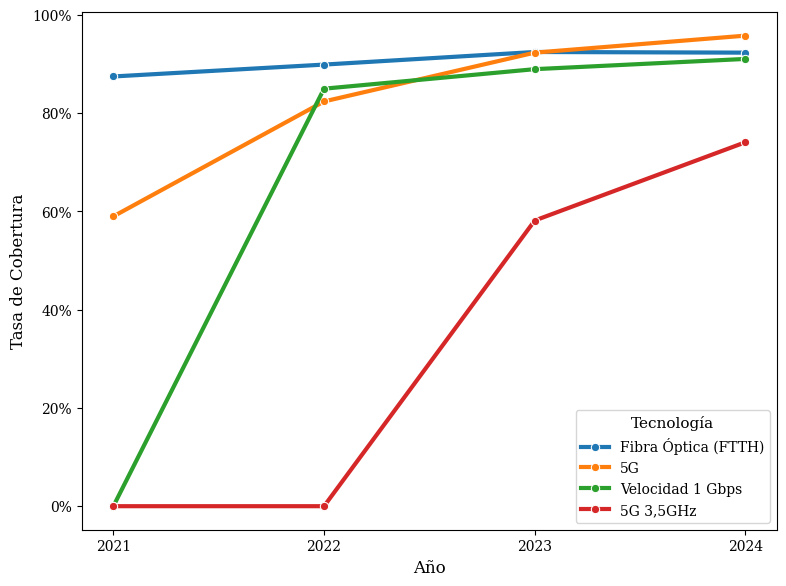

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
plt.rcParams.update({
    "font.family": "serif",   # Fuente con serifa para coherencia con el texto
    "font.size": 11,          # Tamaño base
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 14,
    "axes.titlepad": 15,            # Espacio entre título y gráfico
    "axes.titleweight": "bold",
    "grid.alpha": 0.3         # Rejilla más sutil
})

cobertura_nacional_df = pd.read_csv("../data/silver/cobertura_banda_ancha_nacional_2021_2024.csv", sep=";")
cobertura_nacional_df = agrupar_cobertura_years(cobertura_nacional_df,index='pais')
cobertura_nacional_df.to_csv('cobertura_nacional.csv', index=False, sep=";")
# 1. Cargar el dataset de cobertura
df = cobertura_nacional_df.copy()

# 2. Agrupar por año y calcular la media nacional de cada tecnología

# 3. Configurar el gráfico de líneas temporales
plt.figure(figsize=(8, 6))
#sns.set_theme(style="whitegrid")

sns.lineplot(data=df, x='anno', y='ftth', marker='o', label='Fibra Óptica (FTTH)', linewidth=3)
sns.lineplot(data=df, x='anno', y='5g', marker='o', label='5G', linewidth=3)
sns.lineplot(data=df, x='anno', y='1gbps', marker='o', label='Velocidad 1 Gbps', linewidth=3)
sns.lineplot(data=df, x='anno', y='5g_3_5ghz', marker='o', label='5G 3,5GHz', linewidth=3)

# 4. Títulos y formato
#plt.title('Evolución Nacional de la Cobertura Digital (2021 - 2024)', fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Tasa de Cobertura')

# Forzar que el eje X solo muestre años enteros
plt.xticks([2021, 2022, 2023, 2024])
plt.legend(title='Tecnología', loc='lower right')
ax = plt.gca() 

# Configuramos el formateador: 
# xmax=1 indica que el valor 1 representa el 100%
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# Opcional: ajustar los ticks para que no salgan demasiados
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.tight_layout()
#plt.savefig('../docs/manuscrito/recursos/figuras/cobertura-nacional-evolucion.pdf',)
plt.show()

# Correlación % cobertura y densidad acumulada de startups por provincia

In [7]:

def provincias_cobertura_startups_anno(empresas_df,poblacion_df, df_cobertura, anno, targets, operator='<='):
    """
    Refactorización usando DuckDB para realizar un PIVOT manual de forma eficiente.
    """
    duckdb.register("empresas_df", empresas_df)
    query_str = f"""
    PIVOT (
    -- 1. Preparamos los datos filtrados y calculamos el total por provincia
    SELECT 
        provincia,
        cpro,
        grupo_cnae,
        COUNT(*) OVER (PARTITION BY provincia) AS total_startups
    FROM empresas_df
    WHERE anno_constitucion {operator} {anno}
) 
-- 2. Definimos que los nombres de las columnas serán los grupos CNAE
ON grupo_cnae 

-- 3. La métrica a contar es el número de startups por cada cruce
USING COUNT(*) 

-- 4. Agrupamos por provincia y mantenemos el total que calculamos antes
GROUP BY 
    provincia, cpro,
    total_startups
ORDER BY 
    total_startups DESC;
    """
    tmp_df = duckdb.query(query_str).to_df()
    tmp_df['total_startups_no_IT'] = tmp_df['total_startups'] - tmp_df['62'] - tmp_df['63']
    #tmp_df['cpro'] = tmp_df['cpro'].astype(str)  # Aseguramos que cpro es string para el merge
    tmp_df = poblacion_df.query(f'anno == {anno}')[['cpro','poblacion', 'hombres', 'mujeres']].merge(tmp_df, on='cpro', how='left').fillna(0)
    for target in targets:
        tmp_df[f'{target}_100k_hab'] = (tmp_df[target] / tmp_df['poblacion']) * 100000
    
    return tmp_df.merge(df_cobertura.query(f'anno == {anno}'), on=['cpro'], how='left')

In [9]:
poblacion_2021_df = pd.read_parquet("../data/silver/poblacion_2021.parquet")
poblacion_2021_df['anno'] = 2021
poblacion_2022_df = pd.read_parquet("../data/silver/poblacion_2022.parquet")
poblacion_2022_df['anno'] = 2022
poblacion_2023_df = pd.read_parquet("../data/silver/poblacion_2023.parquet")
poblacion_2023_df['anno'] = 2023
poblacion_2024_df = pd.read_parquet("../data/silver/poblacion_2024.parquet")
poblacion_2024_df['anno'] = 2024
poblacion_2025_df = pd.read_parquet("../data/silver/poblacion_2025.parquet")
poblacion_2025_df['anno'] = 2025

poblacion_df = pd.concat([poblacion_2021_df, poblacion_2022_df, poblacion_2023_df, poblacion_2024_df, poblacion_2025_df], ignore_index=True)
poblacion_df = poblacion_df.groupby(['cpro', 'anno']).agg({
    'poblacion': 'sum',
    'hombres': 'sum',
    'mujeres': 'sum'
}).reset_index()

empresas_df = pd.read_parquet("../data/silver/iberinform_startups_certificadas.parquet", engine='pyarrow')
empresas_df['cpro'] = empresas_df['codigo_postal'].str[:2]
empresas_df['anno_constitucion'] = pd.to_datetime(
    empresas_df['fecha_constitucion'], errors='coerce').dt.year

empresas_df = empresas_df[['cpro','provincia','grupo_cnae','anno_constitucion']].copy()
targets = ['10','46','47','62','63','70','73','71','72','74','total_startups','total_startups_no_IT']
targets_100k = [f'{t}_100k_hab' for t in targets]
cobertura_features = ['ftth', '1gbps', '5g', '5g_3_5ghz']
provincias_cobertura_startups_2021 = provincias_cobertura_startups_anno(empresas_df, poblacion_df,cobertura_provincial_df, 2021, targets, '<=').set_index('cpro')
provincias_cobertura_startups_2022 = provincias_cobertura_startups_anno(empresas_df, poblacion_df, cobertura_provincial_df, 2022, targets, '<=').set_index('cpro')
provincias_cobertura_startups_2023 = provincias_cobertura_startups_anno(empresas_df, poblacion_df, cobertura_provincial_df, 2023, targets, '<=').set_index('cpro')
provincias_cobertura_startups_2024 = provincias_cobertura_startups_anno(empresas_df, poblacion_df, cobertura_provincial_df, 2024, targets, '<=').set_index('cpro')
provincias_cobertura_startups_2025 = provincias_cobertura_startups_anno(empresas_df, poblacion_df, cobertura_provincial_df, 2025, targets, '<=').set_index('cpro')

In [10]:
rename_dict = {
    '10_100k_hab': 'Industria Alimetaria',
    '46_100k_hab': 'Comercio al por mayor',
    '47_100k_hab': 'Comercio al por menor',
    '62_100k_hab': 'Software',
    '63_100k_hab': 'Hosting',
    '70_100k_hab': 'Consultoría empresarial',
    '73_100k_hab': 'Publicidad/investigación de mercado',
    '71_100k_hab': 'Servicios técnicos de arquitectura e ingeniería',
    '72_100k_hab': 'I+D',
    '74_100k_hab': 'Otros servicios profesionales, científicos y técnicos',
    'total_startups_100k_hab': 'total provincial startups',
    'total_startups_no_IT_100k_hab': 'total provincial startups no IT'
}

Información sobre las medias y varianzas de cada tecnología

In [11]:
cobertura_provincial_df.query('anno == 2024')[['ftth','1gbps','5g','5g_3_5ghz']].mean()

ftth         0.893410
1gbps        0.877865
5g           0.918680
5g_3_5ghz    0.640566
dtype: float64

In [12]:
cobertura_provincial_df.query('anno == 2024')[['ftth','1gbps','5g','5g_3_5ghz']].var()

ftth         0.005275
1gbps        0.006445
5g           0.005020
5g_3_5ghz    0.025301
dtype: float64

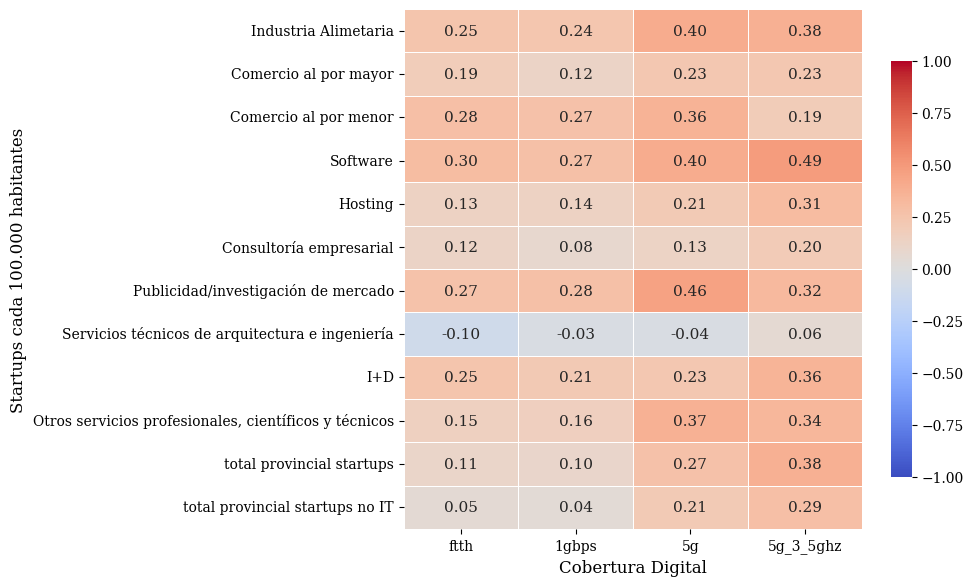

In [9]:
plot_correlation(provincias_cobertura_startups_2024.rename(columns=rename_dict), feature_cols=cobertura_features, feature_label='Cobertura Digital', target_cols=list(rename_dict.values()), target_label='Startups cada 100.000 habitantes', title='', figsize=(10, 6), save_as='../docs/manuscrito/recursos/figuras/cobertura-densidad-startups-correlacion-2024.pdf')

la cobertura 5G en la banda de 3.5 GHz muestra una correlación positiva moderada con la densidad de startups por 100k habitantes, especialmente con el total provincial de startups y el total provincial de startups no IT. Esto sugiere que las provincias con mejor cobertura 5G en esta banda tienden a tener una mayor concentración de startups, lo que podría indicar que la infraestructura digital avanzada es un factor que favorece el ecosistema emprendedor.
Es la metrica de conectividad con mayor coeficiente de correlación a nivel general con cualquier sector de startups y también excluyendo el sector IT, lo que refuerza la idea de que la cobertura 5G en la banda de 3.5 GHz es un indicador clave para el desarrollo de startups en general, no solo aquellas relacionadas con tecnología de la información.
También destacar que se debe a que tiene mnor grado de implantación, lo que hace que su presencia sea un factor diferencial más relevante en comparación con otras métricas de conectividad que ya están más extendidas y, por tanto, tienen una menor capacidad de discriminación entre provincias.